<a href="https://colab.research.google.com/github/KaraboNtsie/Machine_learning/blob/main/Assignements/ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Statements

In [102]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split


from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier


# Task 1: Cleaning your data

## 1.

In [26]:
wine_df = pd.read_csv('winequality-red.csv')



wine_df.isna().sum().sort_values(ascending=False)


,0
total sulfur dioxide,98
density,76
pH,76
free sulfur dioxide,71
chlorides,50
residual sugar,44
citric acid,44
volatile acidity,22
sulphates,21
fixed acidity,0


In [27]:
wine_df['total sulfur dioxide'] = wine_df['total sulfur dioxide'].fillna(wine_df['total sulfur dioxide'].median())
wine_df['density'] = wine_df['density'].fillna(wine_df['density'].median())
wine_df['pH'] = wine_df['pH'].fillna(wine_df['pH'].median())
wine_df['free sulfur dioxide'] = wine_df['free sulfur dioxide'].fillna(wine_df['free sulfur dioxide'].median())
wine_df['residual sugar'] = wine_df['residual sugar'].fillna(wine_df['residual sugar'].median())
wine_df['chlorides'] = wine_df['chlorides'].fillna(wine_df['chlorides'].median())
wine_df['citric acid'] = wine_df['citric acid'].fillna(wine_df['citric acid'].median())
wine_df['volatile acidity'] = wine_df['volatile acidity'].fillna(wine_df['volatile acidity'].median())
wine_df['sulphates'] = wine_df['sulphates'].fillna(wine_df['sulphates'].median())

In [28]:

wine_df.isna().sum().sort_values(ascending=False)

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## 2.

copied from cleaned.py

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5  


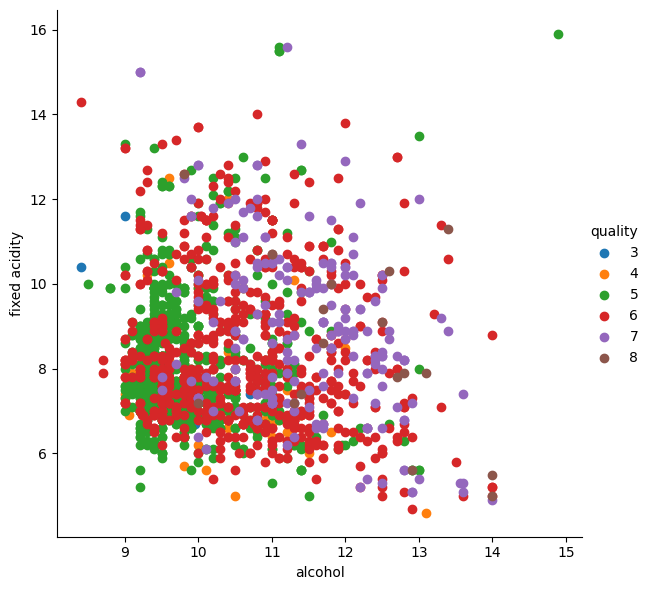

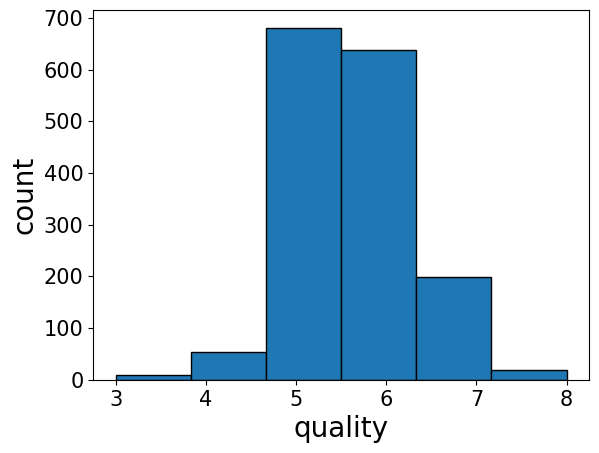

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

##plt.style.use('seaborn-darkgrid')

# Note that Best Practices, in terms of order of steps were violated in this program, please fix that.

# # Data Acquisition (I broke the CSV on purpose)
wine_df = pd.read_csv('winequality-red.csv')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(wine_df.head(3))

X = wine_df.drop('quality', axis=1).values
y = np.ravel(wine_df[['quality']])


## Based on the slides, best practice would be to split the data into training and testing sets before doing any EDA or cleaning.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



# # Cleanup

# # Exploratory Data Analysis
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    # print(wine_df.describe())
# sns.pairplot(wine_df, hue = 'quality', height = 3, palette="husl")
# sns.violinplot(data=wine_df, x='quality', y='alcohol')
sns.FacetGrid(wine_df, hue='quality', height=6).map(plt.scatter, 'alcohol', 'fixed acidity').add_legend()
plt.show()


# ### Distribution of wine quality (target variable)
plt.hist(wine_df['quality'], bins=6, edgecolor='black')
plt.xlabel('quality', fontsize=20)
plt.ylabel('count', fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()


## Some descriptive stats on the data

In [30]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1577.000000,1555.000000,1555.000000,1.549000e+03,1528.000000,1501.000000,1523.000000,1523.000000,1578.000000,1599.000000,1599.000000
mean,8.319637,0.528662,0.268328,2.531029,6.455778e+10,15.928665,46.215190,0.996698,3.314156,0.659043,10.422983,5.636023
std,1.741096,0.178990,0.194905,1.381187,2.540822e+12,10.414376,32.631079,0.001897,0.154067,0.170195,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,1.200000e-02,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,7.000000e-02,8.000000,22.000000,0.995540,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,7.900000e-02,14.000000,38.000000,0.996690,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,9.000000e-02,21.000000,62.000000,0.997800,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.400000,1.000000e+14,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Task 2: Scaling your data

## 1.

In [31]:
X = wine_df.drop(columns='quality')
y = wine_df['quality']



knn = KNeighborsClassifier(n_neighbors=5)

## 2.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 3.

In [33]:
scl = StandardScaler()
X_train_scaled = scl.fit_transform(X_train)
X_test_scaled = scl.transform(X_test)

## 4.

In [34]:
wine_df = pd.read_csv('winequality-red.csv')

wine_df['total sulfur dioxide'] = wine_df['total sulfur dioxide'].fillna(wine_df['total sulfur dioxide'].median())
wine_df['density'] = wine_df['density'].fillna(wine_df['density'].median())
wine_df['pH'] = wine_df['pH'].fillna(wine_df['pH'].median())
wine_df['free sulfur dioxide'] = wine_df['free sulfur dioxide'].fillna(wine_df['free sulfur dioxide'].median())
wine_df['residual sugar'] = wine_df['residual sugar'].fillna(wine_df['residual sugar'].median())
wine_df['chlorides'] = wine_df['chlorides'].fillna(wine_df['chlorides'].median())
wine_df['citric acid'] = wine_df['citric acid'].fillna(wine_df['citric acid'].median())
wine_df['volatile acidity'] = wine_df['volatile acidity'].fillna(wine_df['volatile acidity'].median())
wine_df['sulphates'] = wine_df['sulphates'].fillna(wine_df['sulphates'].median())

X = wine_df.drop(columns='quality')
y = wine_df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'scaler' : [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring = ['accuracy', 'f1_weighted'],
    refit = 'f1_weighted',
    n_jobs = 1
)


grid.fit(X_train, y_train)

print(f"Best Scaler and Parameters: {grid.best_params_}")
print(f"Best Weighted F1-Score: {grid.best_score_:.4f}")


results = pd.DataFrame(grid.cv_results_)
print(results[['param_scaler', 'param_knn__n_neighbors',
                'mean_test_accuracy', 'mean_test_f1_weighted']]
      .sort_values('mean_test_f1_weighted', ascending=False)
      .head(10))


Best Scaler and Parameters: {'knn__n_neighbors': 9, 'scaler': RobustScaler()}
Best Weighted F1-Score: 0.5714
        param_scaler  param_knn__n_neighbors  mean_test_accuracy  \
11    RobustScaler()                       9            0.594327   
20    RobustScaler()                      17            0.595191   
23    RobustScaler()                      19            0.593394   
26    RobustScaler()                      21            0.591620   
12  StandardScaler()                      11            0.588957   
14    RobustScaler()                      11            0.584509   
16    MinMaxScaler()                      15            0.586291   
17    RobustScaler()                      15            0.582683   
8     RobustScaler()                       7            0.580025   
24  StandardScaler()                      21            0.579136   

    mean_test_f1_weighted  
11               0.571418  
20               0.570828  
23               0.568590  
26               0.566440  
12

The parameter and scaler that achieve the best accuracy and weighted f1 score are n neighbours set to 0 and the Robust scaler, achieving an accuracy of 0.594327 and a weighted f1 score of 0.571418.


This may be attributed to class imbalance and the difficulty of classifying 6 classes. Since there are few examples of classes such as 3 and 8, there may never be enough neighbours to guess those classes, which drags the weighted f1 down.

RobustScaler is the best scaler because it is less sensitive to outliers so it can handle them better.

## 5.

In [35]:
n = grid.best_params_['knn__n_neighbors']
scaler = grid.best_params_['scaler']

knn = KNeighborsClassifier(n_neighbors=n)
scl = scaler

X_train_scaled = scl.fit_transform(X_train)
X_test_scaled = scl.transform(X_test)

knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)


cls_report = classification_report(y_test, y_pred, zero_division=0)
print(cls_report)


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        17
           5       0.60      0.64      0.62       195
           6       0.52      0.59      0.55       200
           7       0.56      0.41      0.47        61
           8       0.00      0.00      0.00         6

    accuracy                           0.56       480
   macro avg       0.28      0.27      0.27       480
weighted avg       0.53      0.56      0.54       480



The macro F1 score of 0.27 and the weighted F1 score of almost double that (0.54) indicate that the model is failing on the rarer classes (3, 4, and 8). Macro f1 treats all classes equally, while the weighted f1 score is dominated by common classes (5 and 6).
The class imbalance may be the cause of the low performance, because if it were the choice of k or the scaler, then performance would be mediocre across all classes.

## 6.

In [36]:
bin_schemes = {
    'orig_low3-4':      [-np.inf, 4, 6, np.inf],
    'balanced_low3-5':  [-np.inf, 5, 6, np.inf],
    'wide_low_mid7':    [-np.inf, 5, 7, np.inf],
    'shift_right':      [-np.inf, 4, 7, np.inf],
}

for name, bins in bin_schemes.items():
    binned = pd.cut(wine_df['quality'], bins=bins, labels=["Low", "Mid", "High"])
    print(name, bins)
    print(binned.value_counts())
    print()

orig_low3-4 [-inf, 4, 6, inf]
quality
Mid     1319
High     217
Low       63
Name: count, dtype: int64

balanced_low3-5 [-inf, 5, 6, inf]
quality
Low     744
Mid     638
High    217
Name: count, dtype: int64

wide_low_mid7 [-inf, 5, 7, inf]
quality
Mid     837
Low     744
High     18
Name: count, dtype: int64

shift_right [-inf, 4, 7, inf]
quality
Mid     1518
Low       63
High      18
Name: count, dtype: int64



The bins create varying class imbalances that will affect the weighted and macro F1 scores.

The most balanced bins are balanced_low3-5, where it lumps quality 3-5 into a low bin; 6 is the midpoint, and the high category is 7 and 8.

Original_low3-4 lumps 3 and 4 into the low class, 5 and 6 into the mid class and 7 and 8 into the high class.

Wide_low_mid7 lumps 3,4, and 5 into the low class, 6 and 7 into the mid class, and 8 into the high class.

Shift_right bins 3,4 and into the low class, 5,6 and 7 into the mid class and 8 into the high class.


The assumption is that 3 indicates the lowest quality and 8 indicates the highest quality.

In [37]:
def best_candidate_bin(bin_candidate, scoring):

    binned = pd.cut(wine_df['quality'], bins=bin_candidate, labels=["Low", "Mid", "High"])
    wine_df['quality_category'] = binned

    new_X = wine_df.drop(columns=['quality', 'quality_category'])
    new_Y = wine_df['quality_category']

    X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(
        new_X, new_Y, test_size=0.3, random_state=42
    )

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ])

    param_grid = {
        'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
        'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21]
    }

    new_grid = GridSearchCV(
        pipe, param_grid, cv=5,
        scoring=scoring, refit='f1_weighted', n_jobs=1
    )
    new_grid.fit(X_new_train, y_new_train)

    return {
        'bins': bin_candidate,
        'best_score': new_grid.best_score_,
        'best_params': new_grid.best_params_,
        'X_train': X_new_train, 'X_test': X_new_test,
        'y_train': y_new_train, 'y_test': y_new_test,
    }



scheme_results = {}
for name, bins in bin_schemes.items():
    scheme_results[name] = best_candidate_bin(bins, 'f1_weighted')
    print(name, scheme_results[name]['best_score'])

best_scheme_name = max(scheme_results, key=lambda k: scheme_results[k]['best_score'])
best_result = scheme_results[best_scheme_name]
print("Winning scheme:", best_scheme_name, best_result['best_params'])



orig_low3-4 0.8080775286022341
balanced_low3-5 0.6268352084529745
wide_low_mid7 0.7183853119653066
shift_right 0.927732878549843
Winning scheme: shift_right {'knn__n_neighbors': 7, 'scaler': MinMaxScaler()}


Shift_right yields the best weighted f1 score. This could be due to the mid bin containing most of the data.

In [38]:
n = best_result['best_params']['knn__n_neighbors']
scaler = best_result['best_params']['scaler']

knn = KNeighborsClassifier(n_neighbors=n)
scl = scaler

X_train_scaled = scl.fit_transform(best_result['X_train'])
X_test_scaled = scl.transform(best_result['X_test'])

knn.fit(X_train_scaled, best_result['y_train'])
y_pred = knn.predict(X_test_scaled)

print(classification_report(best_result['y_test'], y_pred, zero_division=0))

              precision    recall  f1-score   support

        High       0.00      0.00      0.00         6
         Low       0.00      0.00      0.00        18
         Mid       0.95      1.00      0.97       456

    accuracy                           0.95       480
   macro avg       0.32      0.33      0.32       480
weighted avg       0.90      0.95      0.93       480



Optimizing bin choice purely for weighted F1 selected the shift_right scheme, which put 95% of the test set into "Mid." The resulting model scored 0.95 accuracy and 0.93 weighted F1, but Low and High both scored 0.00 across precision, recall, and F1 therefore the model never correctly predicted either class. Weighted F1 rewards accuracy on the dominant class regardless of how the rest are handled, so an extremely imbalanced bin scheme can "win" on this metric without the model actually learning anything useful about the minority classes

## 7.

In [39]:
scheme_results_macro = {}
for name, bins in bin_schemes.items():
    scheme_results_macro[name] = best_candidate_bin(bins, 'f1_macro')
    print(name, scheme_results_macro[name]['best_score'])

best_scheme_name_macro = max(scheme_results_macro, key=lambda k: scheme_results_macro[k]['best_score'])
best_result_macro = scheme_results_macro[best_scheme_name_macro]
print("Winning scheme:", best_scheme_name_macro, best_result_macro['best_params'])

orig_low3-4 0.46843698870582273
balanced_low3-5 0.5844019604325974
wide_low_mid7 0.4837102780958765
shift_right 0.35021745451989045
Winning scheme: balanced_low3-5 {'knn__n_neighbors': 11, 'scaler': RobustScaler()}


In [40]:
n = best_result_macro['best_params']['knn__n_neighbors']
scaler = best_result_macro['best_params']['scaler']

knn = KNeighborsClassifier(n_neighbors=n)
scl = scaler

X_train_scaled = scl.fit_transform(best_result_macro['X_train'])
X_test_scaled = scl.transform(best_result_macro['X_test'])

knn.fit(X_train_scaled, best_result_macro['y_train'])
y_pred_macro = knn.predict(X_test_scaled)

print(classification_report(best_result_macro['y_test'], y_pred_macro, zero_division=0))

              precision    recall  f1-score   support

        High       0.52      0.49      0.50        67
         Low       0.65      0.66      0.66       213
         Mid       0.54      0.54      0.54       200

    accuracy                           0.59       480
   macro avg       0.57      0.56      0.57       480
weighted avg       0.58      0.59      0.58       480



Optimizing for macro F1 instead selected balanced_low3-5, which is far more evenly distributed (744/638/217). Overall accuracy dropped to 0.59, but F1 is now reasonably consistent across all three classes (0.66 Low, 0.54 Mid, 0.50 High) rather than collapsing to zero on two of them. This confirms macro F1 penalises ignoring small classes, so it favors bin schemes and models that perform adequately everywhere over ones that only excel on the majority class.

# Task 3: Best features

## 1.

In [41]:
X = wine_df.drop(columns=['quality', 'quality_category'])
y = wine_df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)




feature_results = []


for direction in ["forward", "backward"]:
  for num_feat in range(2, X_train.shape[1]):
    sfs = SequentialFeatureSelector(
      estimator=KNeighborsClassifier(n_neighbors=n),
      n_features_to_select=num_feat,
      direction=direction,
      scoring="f1_macro",
      cv=5
    )
    pipe = Pipeline([
        ('scaler', scl),
        ('sfs', sfs),
        ('knn', KNeighborsClassifier(n_neighbors=n))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1_macro")
    feature_results.append({
      "direction": direction,
      "num_features": num_feat,
      "mean_score": scores.mean()
    })
    print(direction, num_feat, scores.mean())


feature_results_df = pd.DataFrame(feature_results)
best_row = feature_results_df.loc[feature_results_df["mean_score"].idxmax()]
print(best_row)

forward 2 0.25902609491116746
forward 3 0.27366476915173676
forward 4 0.26025359611488874
forward 5 0.26176766312006433
forward 6 0.26206719238106985
forward 7 0.26331730984542995
forward 8 0.26776092621761693
forward 9 0.26596418614652906
forward 10 0.25829370849033284
backward 2 0.2490939680845848
backward 3 0.2692606651022228
backward 4 0.26510597598829583
backward 5 0.2707489433757926
backward 6 0.2687261809571527
backward 7 0.27568088796480217
backward 8 0.2626946254700852
backward 9 0.25936032400396375
backward 10 0.2603616138137427
direction       backward
num_features           7
mean_score      0.275681
Name: 14, dtype: object


In [42]:
baseline_pipe = Pipeline([
    ('scaler', scl),
    ('knn', KNeighborsClassifier(n_neighbors=n))
  ])
baseline_scores = cross_val_score(baseline_pipe, X_train, y_train, cv=5, scoring="f1_macro")
print(f'All 11 features, macro f1: {baseline_scores.mean()}')

All 11 features, macro f1: 0.2665920552670576


In [43]:
final_sfs = SequentialFeatureSelector(
    KNeighborsClassifier(n_neighbors=n),
    n_features_to_select=int(best_row['num_features']),
    direction=best_row['direction'],
    scoring='f1_macro',
    cv=5
)

final_sfs.fit(scaler.fit_transform(X_train), y_train)

selected_features = X_train.columns[final_sfs.get_support()]
print(list(selected_features))

['volatile acidity', 'chlorides', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


The selected 7-feature subset, compared with the full 11 features, shows a slight improvement, consistent with reduced noise after redundant features were removed.


However, the gain is marginal relative to the binned target results from task 2, showing that the fundamental problem is the severe class imbalance and label overlap between adjacent quality scores.

## 2.

In [44]:
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

knn_final = KNeighborsClassifier(n_neighbors=n)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

print(classification_report(y_test, y_pred_final, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        17
           5       0.63      0.70      0.66       195
           6       0.56      0.61      0.59       200
           7       0.51      0.38      0.43        61
           8       0.00      0.00      0.00         6

    accuracy                           0.59       480
   macro avg       0.28      0.28      0.28       480
weighted avg       0.55      0.59      0.57       480



The classification report shows a macro F1 of 0.28 (rounded to two decimal places). Performance is stratified across classes, with classes that have the majority of the data achieving reasonable F1 scores (0.66 and 0.59). In contrast, classes with fewer than 20 examples (3, 4, and 8) get a score of 0 across all metrics. Thus, the underlying issue of class imbalance is the bottleneck for the unbinned target.

# Task 4: making a medical diagnosis

## EDA

In [65]:
cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.data
cancer_df['target'] = cancer.target

feature_names = cancer.feature_names
target_names = cancer.target_names

cancer_df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [57]:
cancer_X = cancer_df.drop(columns='target')
cancer_y = cancer_df['target']

In [58]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [54]:
print(f'Number of duplicate rows in the dataset: {cancer_df.duplicated().sum()}')

Number of duplicate rows in the dataset: 0


In [55]:
cancer_df.isna().sum().sort_values(ascending=False)

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [59]:
cancer_y.value_counts()

,count
target,
1,357
0,212


In [60]:
cancer_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [72]:
corr_matrix = cancer_df.corr()

print("Top 10 correlated features with target")
corr_with_target = corr_matrix['target'].drop('target')

top_10_by_magnitude = corr_with_target.abs().sort_values(ascending=False).head(10)
print(top_10_by_magnitude)


print(corr_with_target[top_10_by_magnitude.index]) # to see with the signs



Top 10 correlated features with target
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64


In [78]:
print("Top 20 correlated features with each other. To check for redundancy")

feature_corr = cancer_df.drop(columns='target').corr()


corr_pairs = feature_corr.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

corr_pairs = corr_pairs[~corr_pairs.index.map(frozenset).duplicated()]

top_redundant_pairs = corr_pairs.abs().sort_values(ascending=False).head(20)
print(top_redundant_pairs)

Top 20 correlated features with each other. To check for redundancy
mean radius      mean perimeter         0.997855
worst radius     worst perimeter        0.993708
mean radius      mean area              0.987357
mean perimeter   mean area              0.986507
worst radius     worst area             0.984015
worst perimeter  worst area             0.977578
radius error     perimeter error        0.972794
mean perimeter   worst perimeter        0.970387
mean radius      worst radius           0.969539
mean perimeter   worst radius           0.969476
mean radius      worst perimeter        0.965137
mean area        worst radius           0.962746
                 worst area             0.959213
                 worst perimeter        0.959120
radius error     area error             0.951830
mean perimeter   worst area             0.941550
mean radius      worst area             0.941082
perimeter error  area error             0.937655
mean concavity   mean concave points    0.921391
m

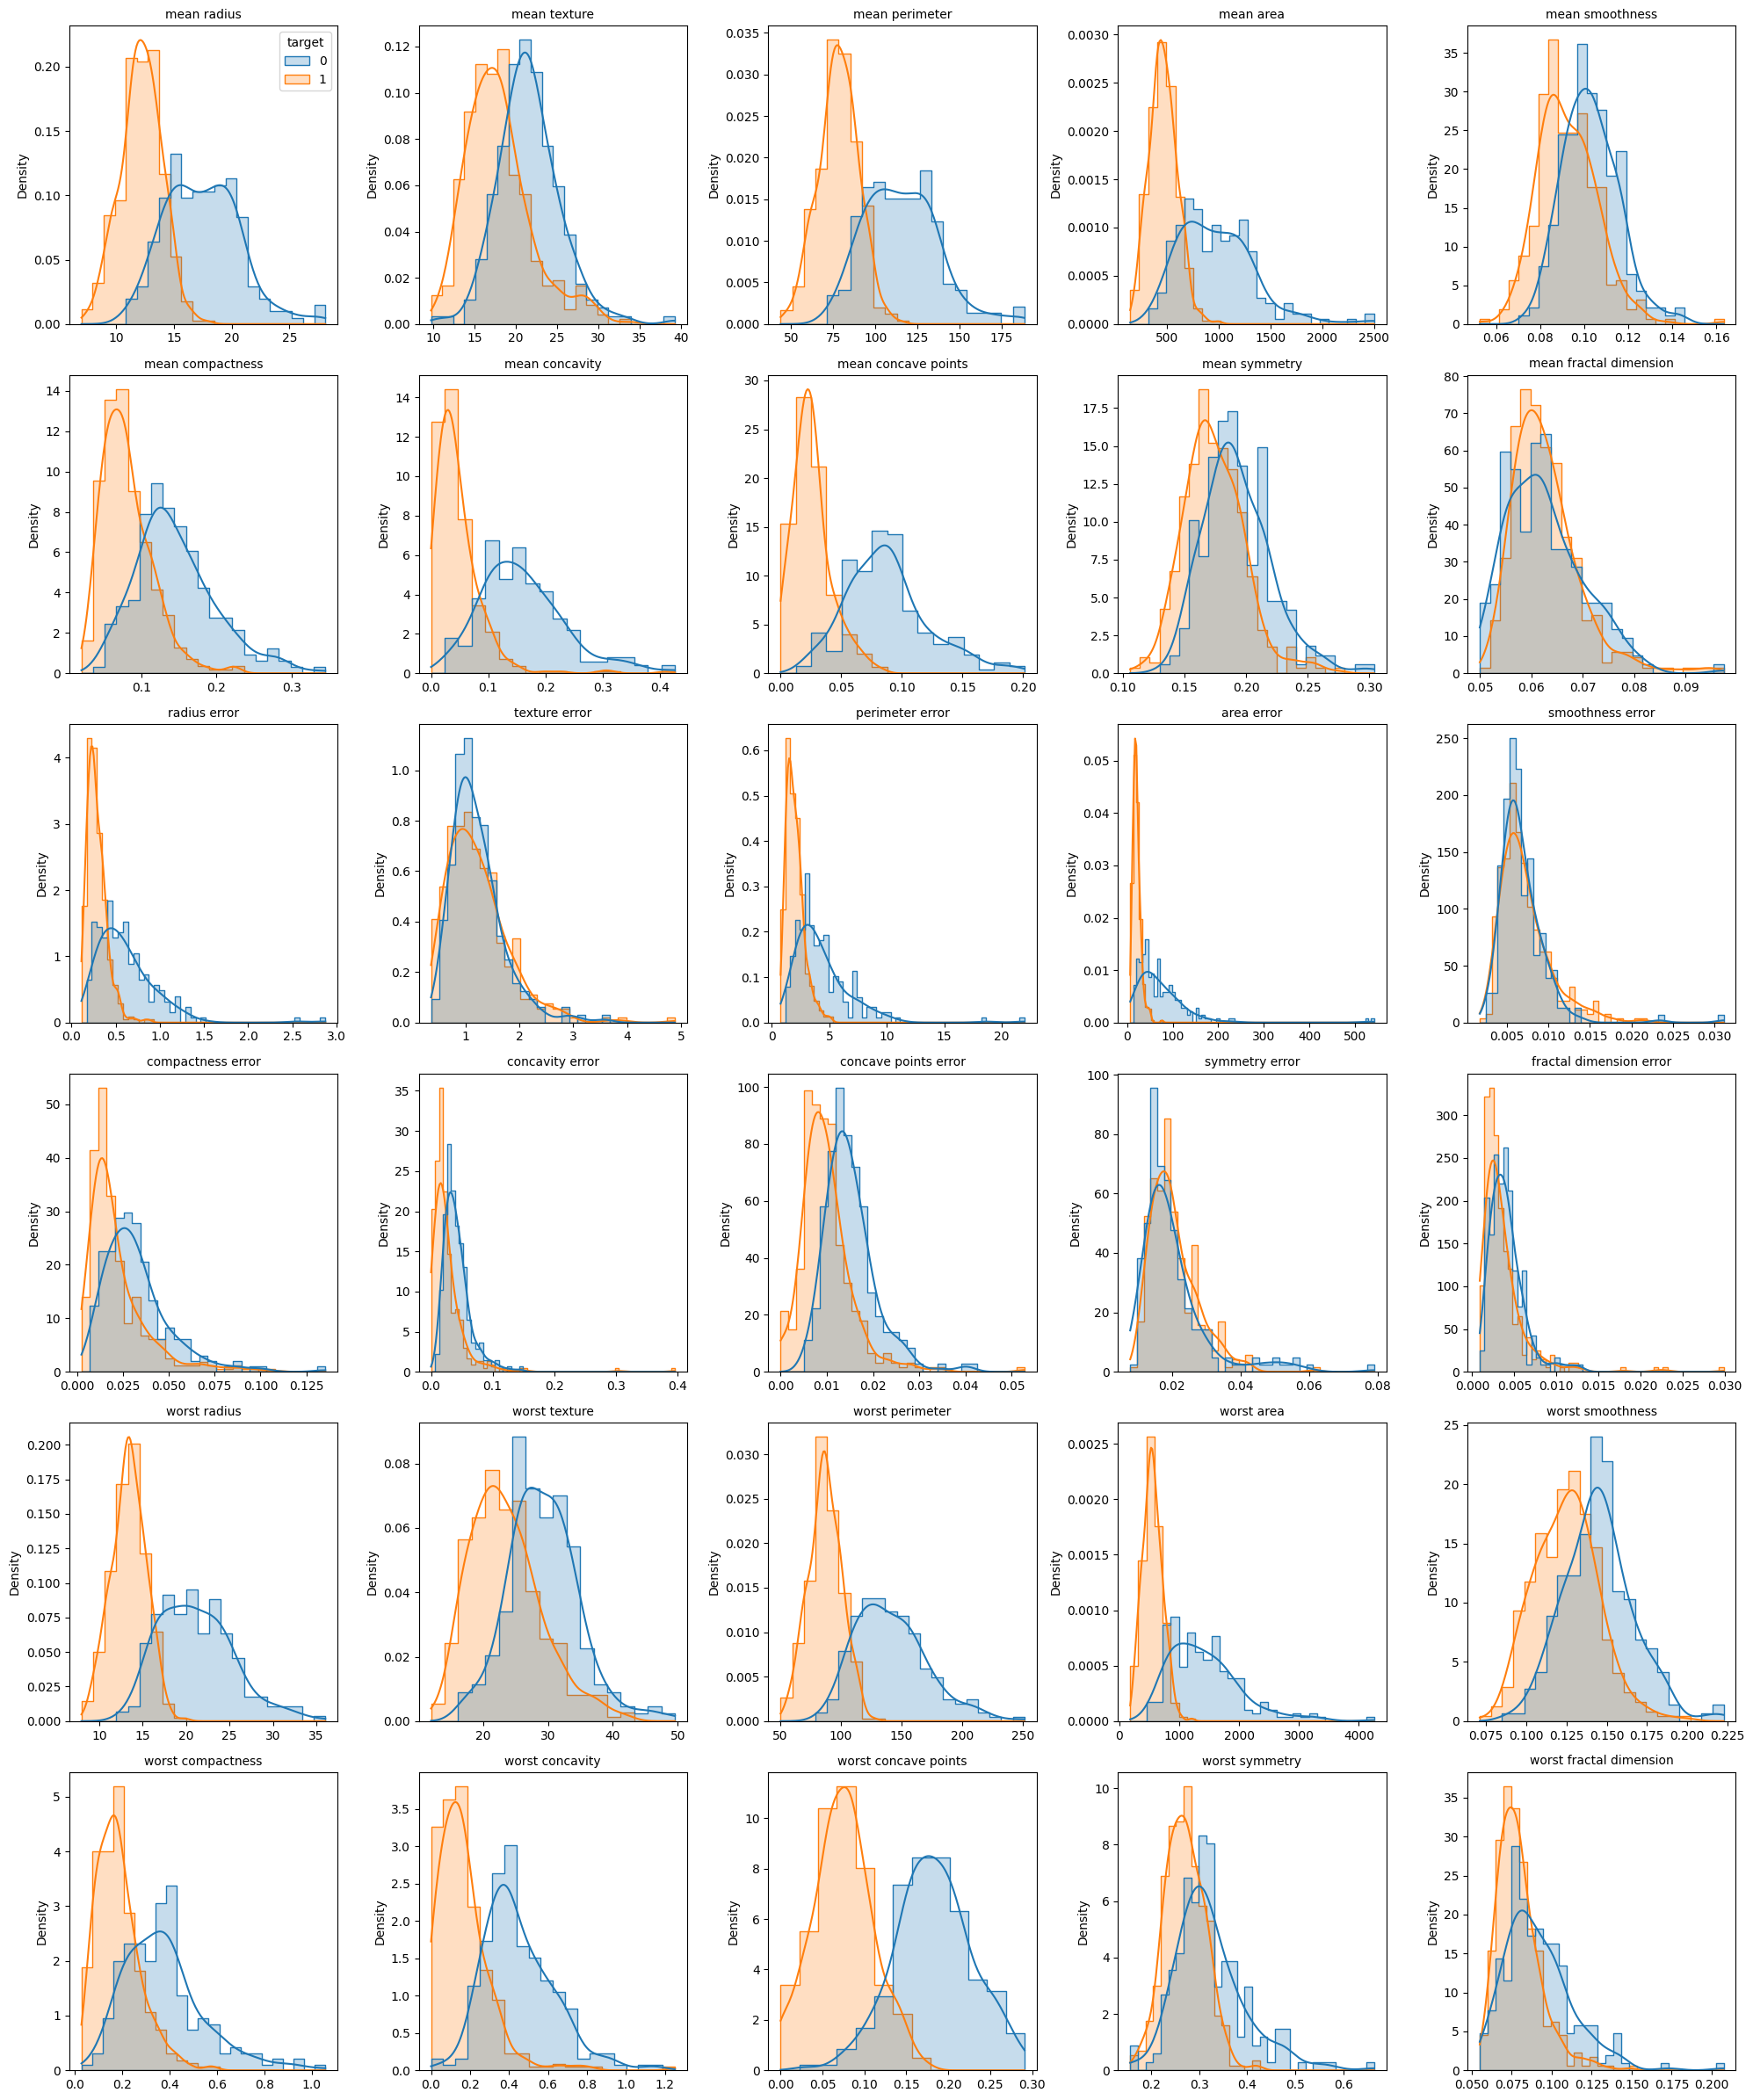

In [75]:
feature_cols = feature_names

n_cols = 5
n_rows = -(-len(feature_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(
        data=cancer_df, x=col, hue='target',
        kde=True, element='step', stat='density',
        common_norm=False,
        ax=axes[i], legend=(i == 0)
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')


for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

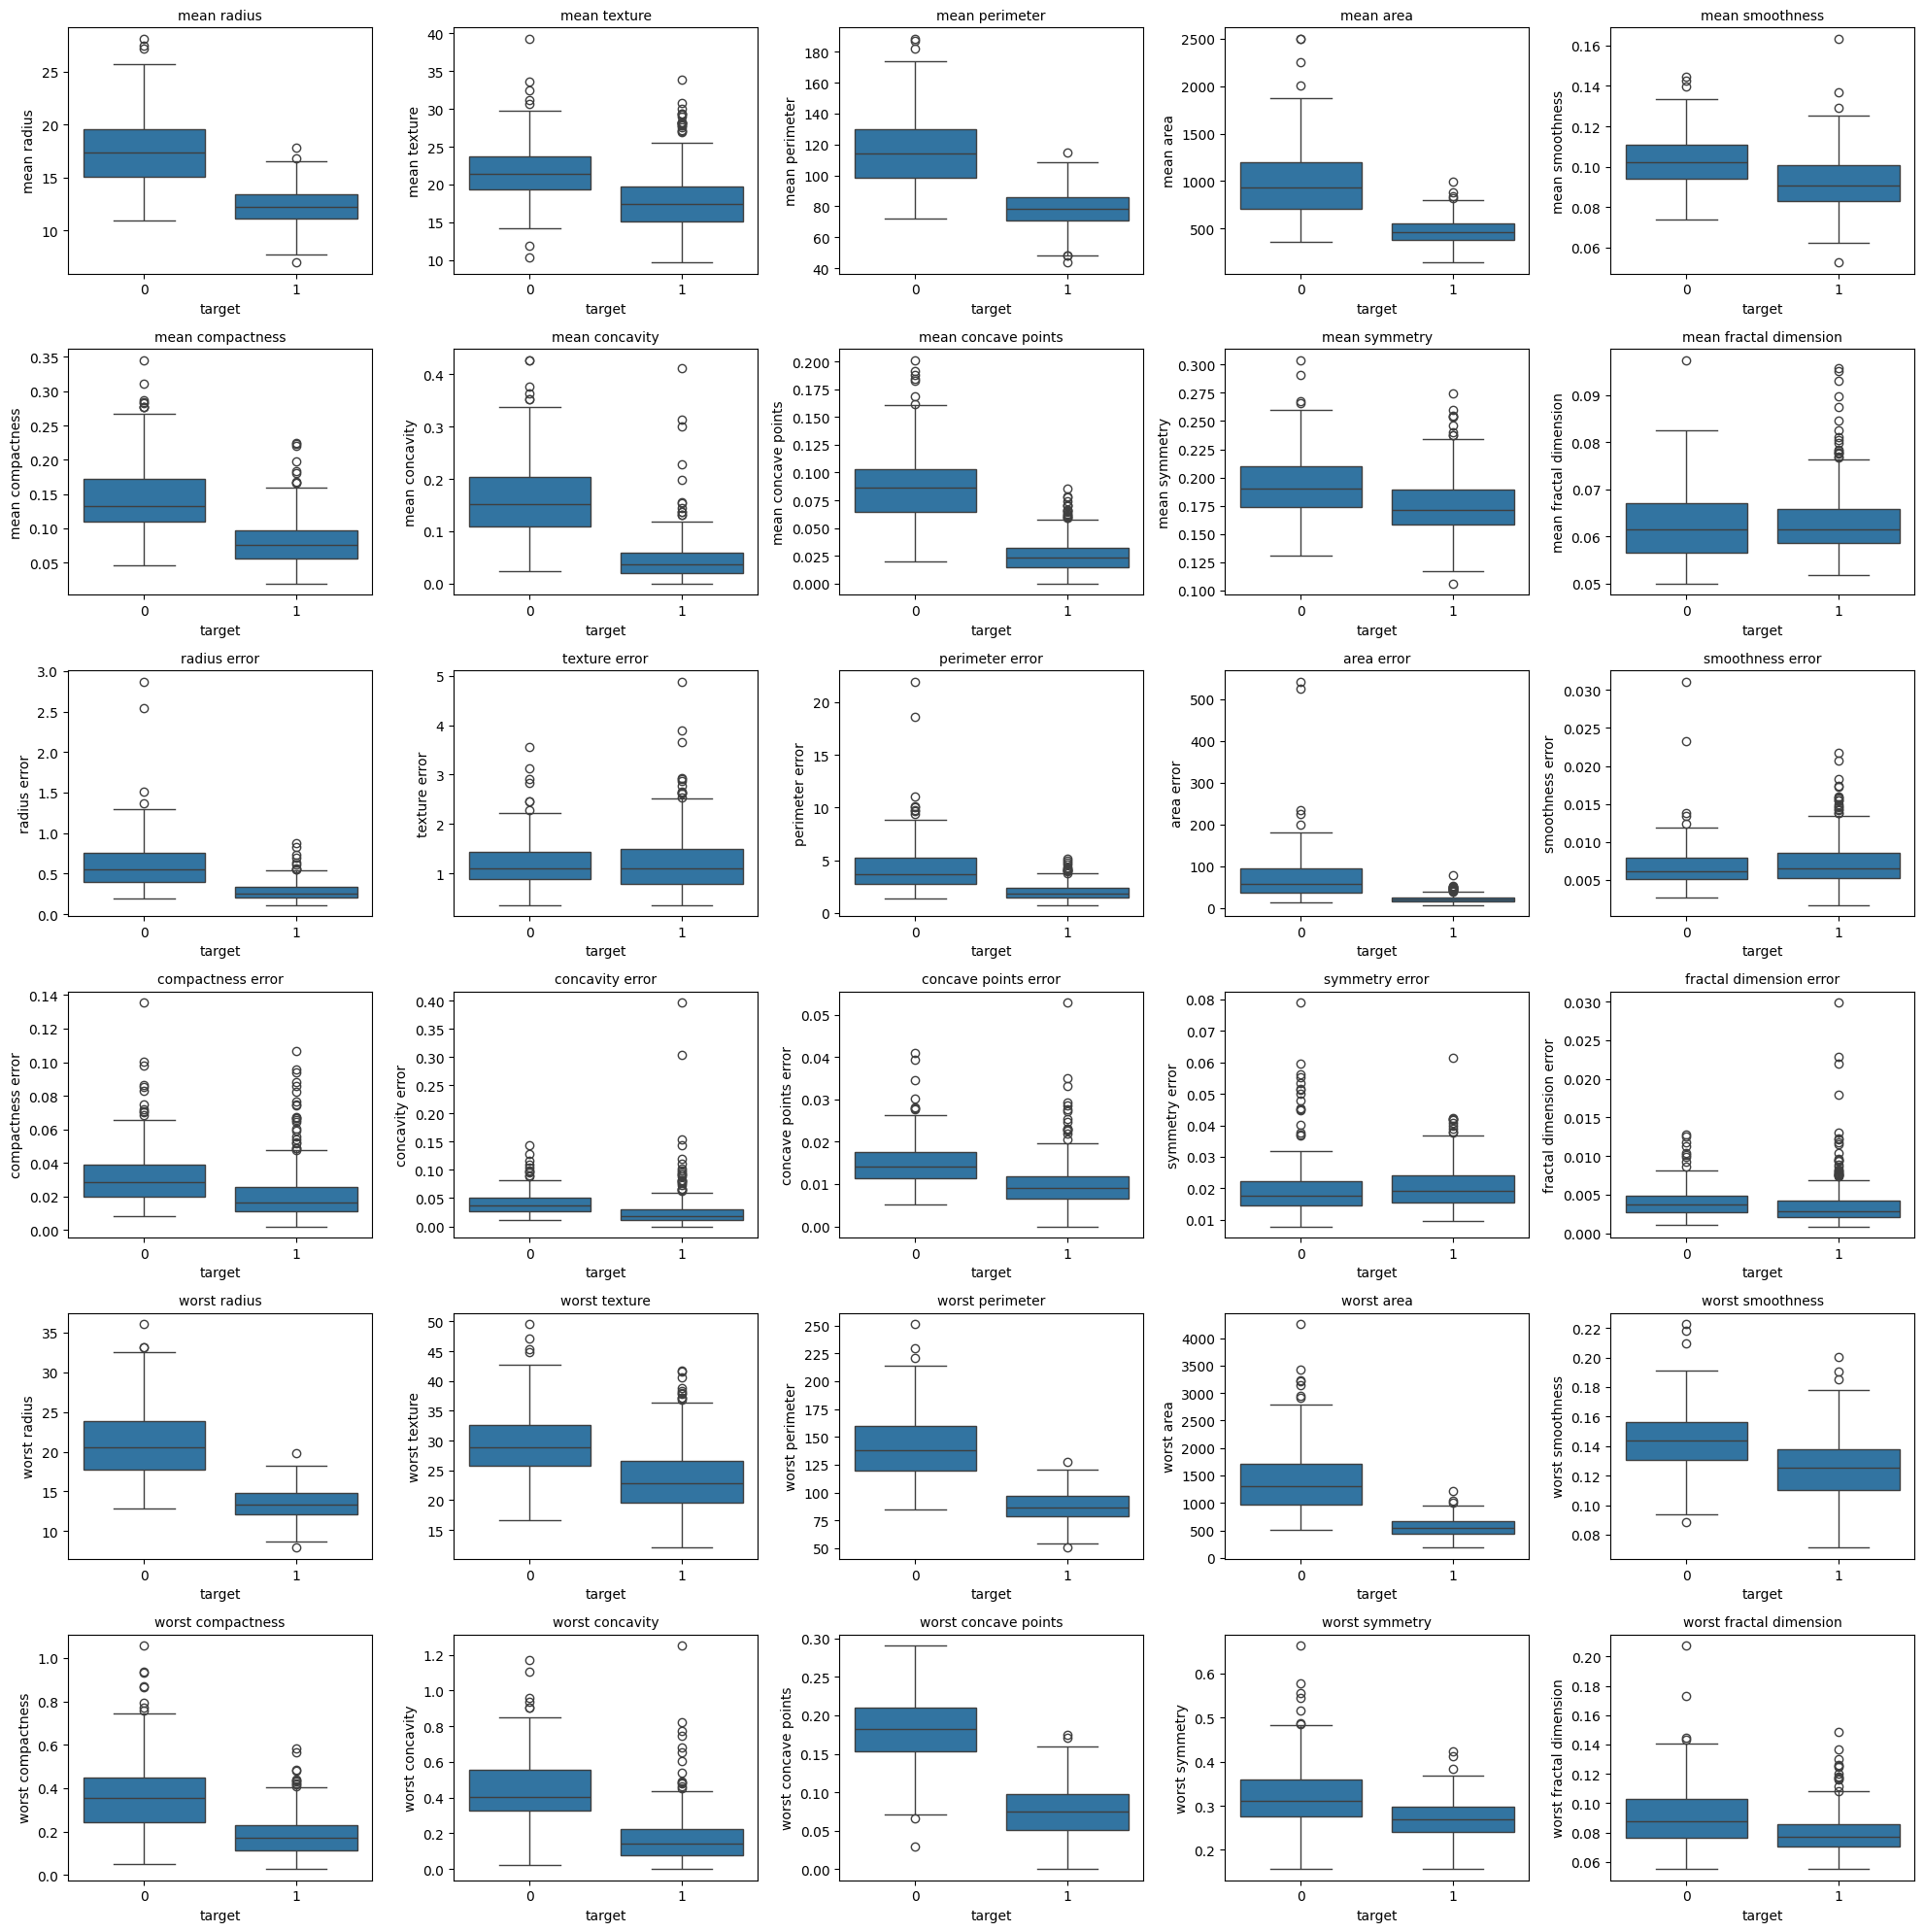

In [79]:
fig, axes = plt.subplots(6, 5, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.boxplot(data=cancer_df, x='target', y=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

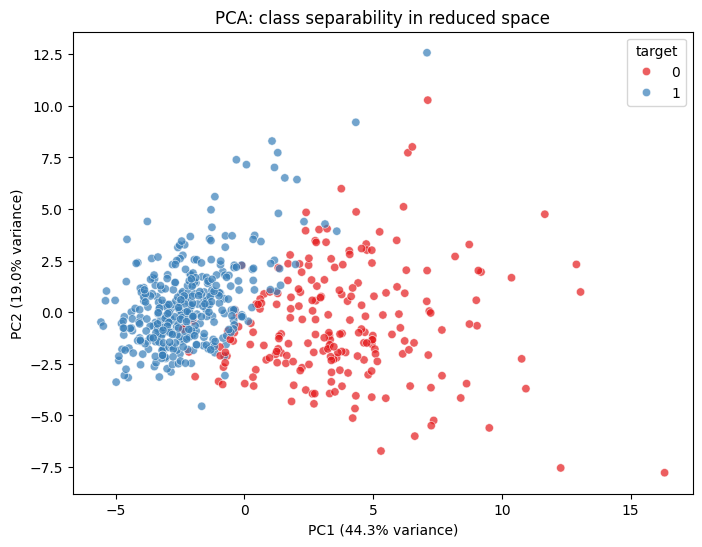

In [101]:
X_scaled_preview = StandardScaler().fit_transform(cancer_df.drop(columns='target'))
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled_preview)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=cancer_df['target'], palette='Set1', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: class separability in reduced space')
plt.show()

EDA identifies size features and measures such as radius, perimeter, area, concavity, concave points, and their worst variants as features that strongly separate malignant from benign classes. In contrast, error features (texture error, smoothness error, symmetry error, and fractal dimension error) show large overlap, suggesting limited predictive power.

The boxplots show right skewness and outliers, motivating the use of a Robust scaler for k-NN and logistic regression.

PCA on the full feature set shows that the classes are reasonably separable with little overlap, suggesting that logistic regression may be preferable to other classifiers.

The high pairwise correlations found amongst mean radius, mean perimeter and mean area and their 'worst' counterparts indicate feature redundancy, motivating feature selection or L1 regularisation to reduce dimensionality.

## k-NN

In [88]:
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21]
}


grid_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=10,
    scoring='f1_macro',
    refit='f1_macro',
    n_jobs=-1
)

grid_knn.fit(cancer_X, cancer_y)

print("Best k-NN params:", grid_knn.best_params_)
print("Best k-NN macro F1:", grid_knn.best_score_)

Best k-NN params: {'knn__n_neighbors': 5, 'scaler': MinMaxScaler()}
Best k-NN macro F1: 0.96946685002329


In [87]:
results_knn = pd.DataFrame(grid_knn.cv_results_)
results_knn['scaler_name'] = results_knn['param_scaler'].apply(lambda s: type(s).__name__)
results_knn['k'] = results_knn['param_knn__n_neighbors']
print(results_knn[['scaler_name', 'k', 'mean_test_score']].sort_values('mean_test_score', ascending=False).head(10))

       scaler_name   k  mean_test_score
4     MinMaxScaler   5         0.969467
13    MinMaxScaler  11         0.969159
7     MinMaxScaler   7         0.967491
1     MinMaxScaler   3         0.965426
16    MinMaxScaler  15         0.965112
3   StandardScaler   5         0.963714
2     RobustScaler   3         0.963636
6   StandardScaler   7         0.963601
10    MinMaxScaler   9         0.963503
9   StandardScaler   9         0.963479


In [95]:
drop_cols = [
    'mean perimeter', 'mean area',
    'worst perimeter', 'worst area',
    'perimeter error', 'area error',
    'mean concave points',
    'worst texture',
    'mean symmetry', 'mean fractal dimension',
    'texture error', 'smoothness error', 'symmetry error', 'fractal dimension error'
]

X_reduced = cancer_X.drop(columns=drop_cols)
print(X_reduced.shape)
print(list(X_reduced.columns))



pipe_knn_reduced = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

grid_knn_reduced = GridSearchCV(
    pipe_knn_reduced,
    param_grid_knn,
    cv=10,
    scoring='f1_macro',
    refit='f1_macro',
    n_jobs=-1
)

grid_knn_reduced.fit(X_reduced, cancer_y)

print("Best k-NN params (reduced features):", grid_knn_reduced.best_params_)
print("Best k-NN macro F1 (reduced features):", grid_knn_reduced.best_score_)

(569, 16)
['mean radius', 'mean texture', 'mean smoothness', 'mean compactness', 'mean concavity', 'radius error', 'compactness error', 'concavity error', 'concave points error', 'worst radius', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Best k-NN params (reduced features): {'knn__n_neighbors': 5, 'scaler': MinMaxScaler()}
Best k-NN macro F1 (reduced features): 0.9637875287562527


Manually removing 14 features identified as highly redundant or highly overlapping with other features reduced the feature set from 30 to 16, with a marginal drop in macro F1 (from 0.9695 to 0.9638). The same scaler and k remained optimal for both feature sets. Confirming that the redundancy observed during EDA demonstrates that a simpler model performs nearly identically to the full 30-feature model; therefore, the reduced feature set is preferred due to its reduced dimensionality, which is relevant for k-NN given its sensitivity to the curse of dimensionality.

While the reduced feature set achieved nearly identical performance to the full feature set for k-NN, the full 30 features will be used for logistic regression and decision tree.

This is because feature dimensionality benefits distance-based methods, but logistic regression's L1 regularisation can achieve the same effect by shrinking redundant coefficients toward zero and decision trees split on nodes that improve node purity.

## Logistic Regression

In [98]:

pipe_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=10000))
])

param_grid_logreg = [
    {
        'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
        'logreg__penalty': ['l2'],
        'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'logreg__solver': ['lbfgs']
    },
    {
        'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
        'logreg__penalty': ['l1'],
        'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'logreg__solver': ['liblinear']
    }
]

grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid_logreg,
    cv=10,
    scoring='f1_macro',
    refit='f1_macro',
    n_jobs=-1
)

grid_logreg.fit(cancer_X, cancer_y)

print("Best logreg params:", grid_logreg.best_params_)
print("Best logreg macro F1:", grid_logreg.best_score_)

Best logreg params: {'logreg__C': 1, 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs', 'scaler': StandardScaler()}
Best logreg macro F1: 0.9791317932159295


In [99]:
results_logreg = pd.DataFrame(grid_logreg.cv_results_)
results_logreg['scaler_name'] = results_logreg['param_scaler'].apply(lambda s: type(s).__name__)
print(results_logreg[['scaler_name', 'param_logreg__penalty', 'param_logreg__C', 'mean_test_score']]
      .sort_values('mean_test_score', ascending=False).head(10))

       scaler_name param_logreg__penalty  param_logreg__C  mean_test_score
9   StandardScaler                    l2              1.0         0.979132
11    RobustScaler                    l2              1.0         0.979132
27  StandardScaler                    l1              1.0         0.977310
29    RobustScaler                    l1              1.0         0.975412
8     RobustScaler                    l2              0.1         0.974973
13    MinMaxScaler                    l2             10.0         0.973249
26    RobustScaler                    l1              0.1         0.973229
6   StandardScaler                    l2              0.1         0.973167
12  StandardScaler                    l2             10.0         0.972005
32    RobustScaler                    l1             10.0         0.971946


Logistic regression achieved a macro F1 of 0.9779, outperforming k-NN, which is consistent with the PCA visualisation shown during EDA, which showed the 2 classes being reasonably well-separated.

RobustScaler and StandardScaler tie for first, reflecting that centring and scaling around a central tendency benefit gradient-based optimisation and magnitude regularisation.

C=1 and L2 penalty performed best, suggesting the model doesn't need to aggressively zero out coefficients to perform well.

## Decision Tree

In [104]:
pipe_tree = Pipeline([
    ('tree', DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'tree__min_samples_split': [2, 5, 10, 20],
    'tree__min_samples_leaf': [1, 2, 5, 10]
}

grid_tree = GridSearchCV(
    pipe_tree,
    param_grid_tree,
    cv=10,
    scoring='f1_macro',
    refit='f1_macro',
    n_jobs=-1
)

grid_tree.fit(cancer_X, cancer_y)

print("Best tree params:", grid_tree.best_params_)
print("Best tree macro F1:", grid_tree.best_score_)

Best tree params: {'tree__criterion': 'entropy', 'tree__max_depth': 8, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Best tree macro F1: 0.9398265411124027


In [105]:
results_tree = pd.DataFrame(grid_tree.cv_results_)
print(results_tree[['param_tree__criterion', 'param_tree__max_depth',
                     'param_tree__min_samples_split', 'param_tree__min_samples_leaf',
                     'mean_test_score']].sort_values('mean_test_score', ascending=False).head(10))

    param_tree__criterion param_tree__max_depth  \
240               entropy                  None   
208               entropy                     8   
224               entropy                    10   
160               entropy                     4   
185               entropy                     5   
186               entropy                     5   
184               entropy                     5   
232               entropy                    10   
248               entropy                  None   
250               entropy                  None   

     param_tree__min_samples_split  param_tree__min_samples_leaf  \
240                              2                             1   
208                              2                             1   
224                              2                             1   
160                              2                             1   
185                              5                             5   
186                           

In [107]:
best_tree = grid_tree.best_estimator_.named_steps['tree']

importances = pd.Series(best_tree.feature_importances_, index=cancer_X.columns)
importances_sorted = importances.sort_values(ascending=False)
print(importances_sorted.head(10))

worst perimeter         0.685889
worst concave points    0.100783
worst texture           0.056901
worst smoothness        0.044626
area error              0.017597
worst symmetry          0.017288
texture error           0.016267
worst area              0.013473
concavity error         0.011973
radius error            0.010948
dtype: float64


The best decision tree achieved a macro F1 of  0.9398265411124027, which is the lowest of the three classifiers tested. Feature importance confirms EDA findings that the worst perimeter and worst concave points, which were identified as the top 2 correlates of malignancy, dominated the tree's decision, with worst perimeter accounting for about 0.69 of total importance.